This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 11.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.26.0 requires keras-hub==0.26.0, but you have keras-hub 0.32.0 which is incompatible.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Fundamentals of machine learning

### Generalization: The goal of machine learning

#### Underfitting and overfitting

##### Noisy training data

##### Ambiguous features

##### Rare features and spurious correlations

In [3]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
train_images.shape

(60000, 784)

In [6]:
train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)
#기존 784개에 균증분포난수로 생성된 784개 노이즈 가로 결합

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)
#기존 784개에 영벡터로 생성된 784개 노이즈 가로 결합

In [7]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model



#노이즈채널모델
model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

#제로채널모델
model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8704 - loss: 0.4381 - val_accuracy: 0.9187 - val_loss: 0.2744
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9341 - loss: 0.2248 - val_accuracy: 0.9473 - val_loss: 0.1864
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9562 - loss: 0.1489 - val_accuracy: 0.9542 - val_loss: 0.1666
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9681 - loss: 0.1061 - val_accuracy: 0.9577 - val_loss: 0.1418
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9776 - loss: 0.0749 - val_accuracy: 0.9592 - val_loss: 0.1391
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9849 - loss: 0.0540 - val_accuracy: 0.9556 - val_loss: 0.1483
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9884 - loss: 0.0410 - val_accuracy: 0.9642 - val_loss: 0.1265
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9937 - loss: 0.0259 - val_accuracy: 0.

#### The nature of generalization in deep learning

In [10]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1020 - loss: 2.3160 - val_accuracy: 0.1102 - val_loss: 2.3079
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1152 - loss: 2.2997 - val_accuracy: 0.1077 - val_loss: 2.3122
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1260 - loss: 2.2921 - val_accuracy: 0.1023 - val_loss: 2.3137
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1387 - loss: 2.2807 - val_accuracy: 0.1019 - val_loss: 2.3176
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1497 - loss: 2.2637 - val_accuracy: 0.1002 - val_loss: 2.3367
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1632 - loss: 2.2447 - val_accuracy: 0.1035 - val_loss: 2.3427
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1766 - loss: 2.2224 - val_accuracy: 0.0993 - val_loss: 2.3567
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1947 - loss: 2.1956 - val_accu

##### The manifold hypothesis

##### Interpolation as a source of generalization

##### Why deep learning works

##### Training data is paramount

### Evaluating machine-learning models

#### Training, validation, and test sets

##### Simple hold-out validation

##### K-fold validation

##### Iterated K-fold validation with shuffling

#### Beating a common-sense baseline

#### Things to keep in mind about model evaluation

### Improving model fit

#### Tuning key gradient descent parameters

In [11]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.0969 - loss: 14.5252 - val_accuracy: 0.0997 - val_loss: 14.5103
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0968 - loss: 14.5573 - val_accuracy: 0.0997 - val_loss: 14.5103
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0968 - loss: 14.5573 - val_accuracy: 0.0997 - val_loss: 14.5103
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0968 - loss: 14.5573 - val_accuracy: 0.0997 - val_loss: 14.5103
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0968 - loss: 14.5573 - val_accuracy: 0.0997 - val_loss: 14.5103
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0968 - loss: 14.5573 - val_accuracy: 0.0997 - val_loss: 14.5103
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0968 - loss: 14.5573 - val_accuracy: 0.0997 - val_loss: 14.5103
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0968 - loss: 14.5573 - v

In [12]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9100 - loss: 0.3932 - val_accuracy: 0.9587 - val_loss: 0.1451
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9642 - loss: 0.1296 - val_accuracy: 0.9695 - val_loss: 0.1251
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9739 - loss: 0.1008 - val_accuracy: 0.9729 - val_loss: 0.1268
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9799 - loss: 0.0803 - val_accuracy: 0.9676 - val_loss: 0.1767
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9828 - loss: 0.0709 - val_accuracy: 0.9703 - val_loss: 0.1650
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9863 - loss: 0.0601 - val_accuracy: 0.9707 - val_loss: 0.1785
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9869 - loss: 0.0574 - val_accuracy: 0.9747 - val_loss: 0.1664
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9888 - loss: 0.0509 - val_accuracy: 0.

#### Using better architecture priors

#### Increasing model capacity

In [13]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_small_model = model.fit(
    train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8362 - loss: 0.6718 - val_accuracy: 0.9038 - val_loss: 0.3602
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9024 - loss: 0.3539 - val_accuracy: 0.9141 - val_loss: 0.3107
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9120 - loss: 0.3177 - val_accuracy: 0.9184 - val_loss: 0.2948
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9160 - loss: 0.3016 - val_accuracy: 0.9222 - val_loss: 0.2840
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9187 - loss: 0.2920 - val_accuracy: 0.9227 - val_loss: 0.2791
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9208 - loss: 0.2852 - val_accuracy: 0.9253 - val_loss: 0.2740
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9218 - loss: 0.2802 - val_accuracy: 0.9267 - val_loss: 0.2709
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9227 - loss: 0.2763 - val_accuracy: 0.

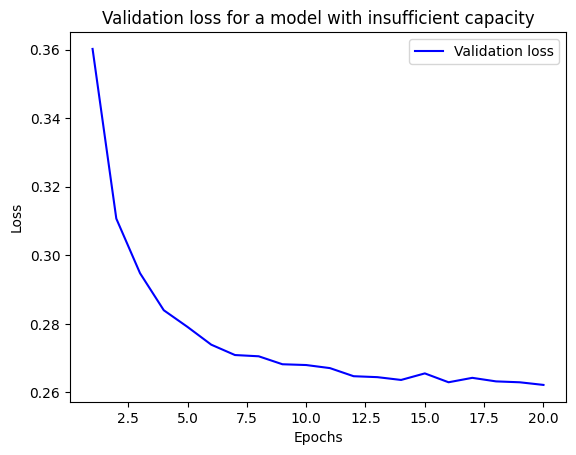

In [14]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu"), #denselayer 하나 더 추가
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9031 - loss: 0.3412 - val_accuracy: 0.9458 - val_loss: 0.1832
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9578 - loss: 0.1425 - val_accuracy: 0.9626 - val_loss: 0.1262
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9701 - loss: 0.0967 - val_accuracy: 0.9665 - val_loss: 0.1123
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9770 - loss: 0.0739 - val_accuracy: 0.9707 - val_loss: 0.1024
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9827 - loss: 0.0581 - val_accuracy: 0.9737 - val_loss: 0.0881
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9858 - loss: 0.0456 - val_accuracy: 0.9730 - val_loss: 0.0924
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9886 - loss: 0.0376 - val_accuracy: 0.9755 - val_loss: 0.0883
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9904 - loss: 0.0304 - val_accuracy: 0.

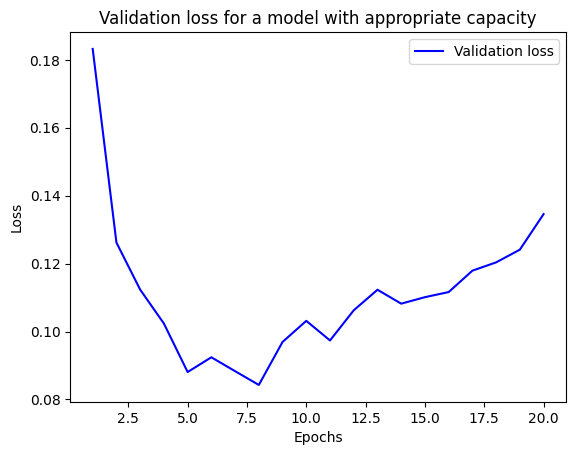

In [16]:
val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with appropriate capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()
# 하나 더 많은 desnelayer를 추가할 때 5.0에포크 이후로 과대적합 문제가 발생함. 하지만 손실도가 적다.

In [17]:
model = keras.Sequential(
    [
        layers.Dense(2048, activation="relu"), #512-->2048로 늘리고, denselayer 하나 더 추가(총3개)
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_very_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9265 - loss: 0.2606 - val_accuracy: 0.9496 - val_loss: 0.1914
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9692 - loss: 0.1178 - val_accuracy: 0.9650 - val_loss: 0.1536
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9778 - loss: 0.0863 - val_accuracy: 0.9717 - val_loss: 0.1191
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9834 - loss: 0.0682 - val_accuracy: 0.9753 - val_loss: 0.1243
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9860 - loss: 0.0597 - val_accuracy: 0.9798 - val_loss: 0.1244
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9898 - loss: 0.0462 - val_accuracy: 0.9757 - val_loss: 0.1856
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9917 - loss: 0.0381 - val_accuracy: 0.9792 - val_loss: 0.1423
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9920 - loss: 0.0370 - 

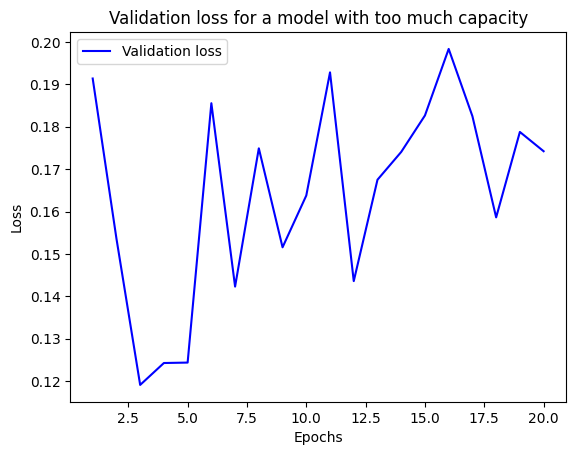

In [18]:
val_loss = history_very_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with too much capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


#validation loss가 크게 뜀

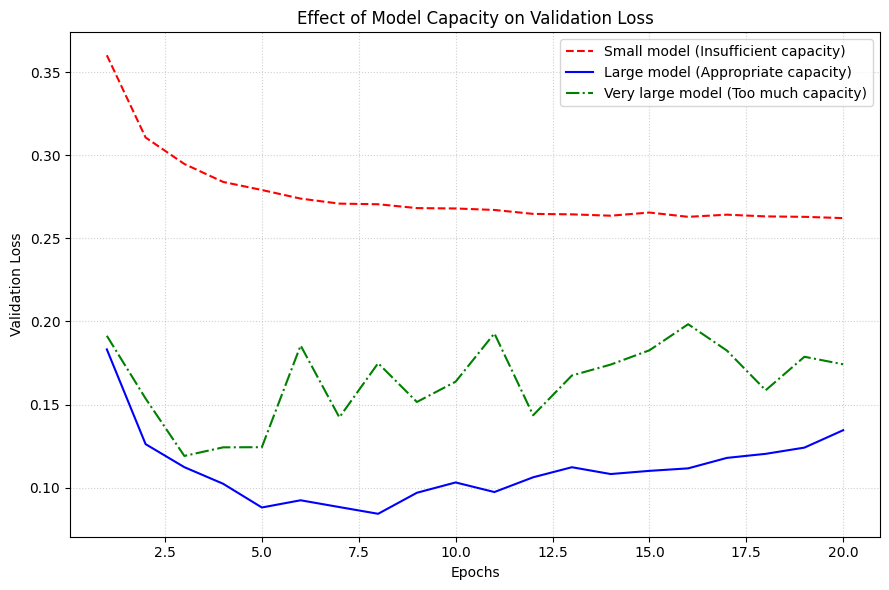

In [19]:
import matplotlib.pyplot as plt

# 1. 에포크 범위 설정 (20 에포크 기준)
epochs = range(1, len(history_small_model.history["val_loss"]) + 1)

# 2. 각 모델의 검증 손실값 추출
val_loss_small = history_small_model.history["val_loss"]
val_loss_large = history_large_model.history["val_loss"]
val_loss_very_large = history_very_large_model.history["val_loss"]

# 3. 플롯 크기 및 스타일 설정
plt.figure(figsize=(9, 6))

# (1) 용량 부족 모델: 빨간색 점선 (과소적합 경향)
plt.plot(epochs, val_loss_small, "r--", label="Small model (Insufficient capacity)")

# (2) 적절한 용량 모델: 파란색 실선 (최적 기준선)
plt.plot(epochs, val_loss_large, "b-", label="Large model (Appropriate capacity)")

# (3) 과도한 용량 모델: 초록색 대시-도트선 (빠른 과대적합 경향)
plt.plot(epochs, val_loss_very_large, "g-.", label="Very large model (Too much capacity)")

# 4. 차트 라벨, 그리드 및 범례 설정
plt.title("Effect of Model Capacity on Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# 5. 출력
plt.tight_layout()
plt.show()

### Improving generalization

#### Dataset curation

#### Feature engineering

#### Using early stopping

#### Regularizing your model

##### Reducing the network's size

In [20]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_original = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.7686 - loss: 0.5416 - val_accuracy: 0.8674 - val_loss: 0.4067
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8940 - loss: 0.3324 - val_accuracy: 0.8682 - val_loss: 0.3330
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9163 - loss: 0.2519 - val_accuracy: 0.8905 - val_loss: 0.2858
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9320 - loss: 0.2028 - val_accuracy: 0.8801 - val_loss: 0.2975
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9417 - loss: 0.1717 - val_accuracy: 0.8845 - val_loss: 0.2867
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9538 - loss: 0.1462 - val_accuracy: 0.8877 - val_loss: 0.2805
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9605 - loss: 0.1249 - val_accuracy: 0.8855 - val_loss: 0.2933
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accurac

In [21]:
model = keras.Sequential(
    [
        layers.Dense(4, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_smaller_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.6691 - loss: 0.6082 - val_accuracy: 0.7486 - val_loss: 0.5478
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8091 - loss: 0.5142 - val_accuracy: 0.8278 - val_loss: 0.5040
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8620 - loss: 0.4676 - val_accuracy: 0.8434 - val_loss: 0.4805
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8963 - loss: 0.4334 - val_accuracy: 0.8715 - val_loss: 0.4593
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9175 - loss: 0.4020 - val_accuracy: 0.8662 - val_loss: 0.4425
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9374 - loss: 0.3631 - val_accuracy: 0.8856 - val_loss: 0.4079
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9494 - loss: 0.3147 - val_accuracy: 0.8794 - val_loss: 0.3777
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9575 - loss: 0.2633 - val_accuracy: 0.8790 - v

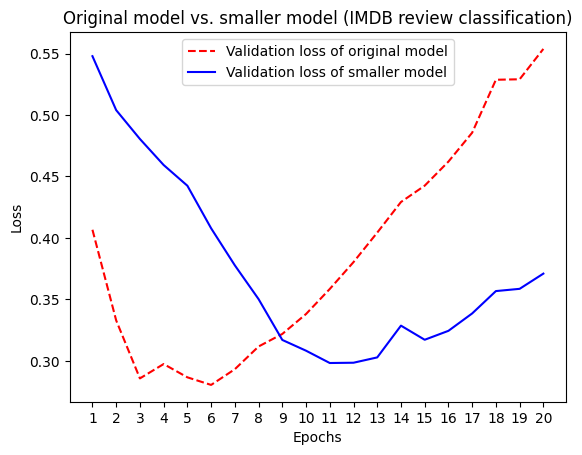

In [22]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.title("Original model vs. smaller model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [23]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_larger_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.7257 - loss: 0.5706 - val_accuracy: 0.8483 - val_loss: 0.3706
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8703 - loss: 0.3172 - val_accuracy: 0.8673 - val_loss: 0.3204
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8981 - loss: 0.2467 - val_accuracy: 0.8675 - val_loss: 0.3202
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9262 - loss: 0.1867 - val_accuracy: 0.8893 - val_loss: 0.2823
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9465 - loss: 0.1436 - val_accuracy: 0.8893 - val_loss: 0.2907
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9537 - loss: 0.1231 - val_accuracy: 0.8885 - val_loss: 0.2807
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9752 - loss: 0.0794 - val_accuracy: 0.8846 - val_loss: 0.3319
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9809 - loss: 0.0587 - val_accuracy: 0.8842 - v

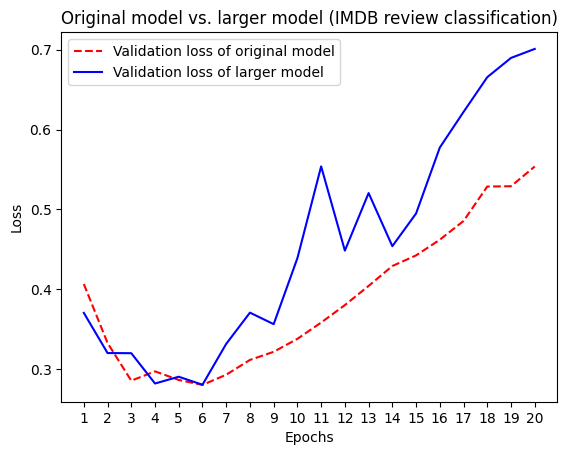

In [24]:
original_val_loss = history_original.history["val_loss"]
larger_model_val_loss = history_larger_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    larger_model_val_loss,
    "b-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

##### Adding weight regularization

In [25]:
from keras.regularizers import l2


#L2정규화(과대적합 문제 해결을 위한)

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.7723 - loss: 0.6093 - val_accuracy: 0.8747 - val_loss: 0.4664
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8918 - loss: 0.4026 - val_accuracy: 0.8766 - val_loss: 0.4031
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9150 - loss: 0.3295 - val_accuracy: 0.8645 - val_loss: 0.4059
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9281 - loss: 0.2940 - val_accuracy: 0.8893 - val_loss: 0.3560
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9321 - loss: 0.2750 - val_accuracy: 0.8798 - val_loss: 0.3713
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9394 - loss: 0.2609 - val_accuracy: 0.8871 - val_loss: 0.3623
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9453 - loss: 0.2482 - val_accuracy: 0.8737 - val_loss: 0.3953
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9479 - loss: 0.2404 - val_accuracy: 0.8771 - v

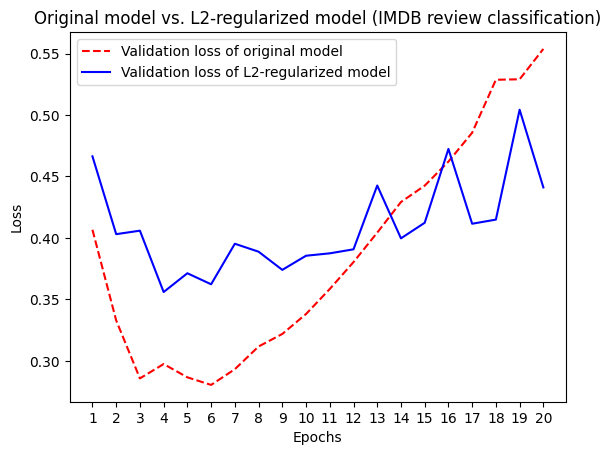

In [26]:
# 과대적합 문제는 해결을 할 수 있지만, 4번째에포크까지는 기존모델의 성능이 더 좋다.

original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of L2-regularized model",
)
plt.title(
    "Original model vs. L2-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [27]:
from keras import regularizers

regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

##### Adding dropout

In [29]:
#과대적합 문제 해결을 위한 방법-->드롭아웃
#layer사이에 드롭아웃을 추가한다.

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.6322 - loss: 0.6387 - val_accuracy: 0.8026 - val_loss: 0.5392
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7635 - loss: 0.5231 - val_accuracy: 0.8710 - val_loss: 0.4383
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8249 - loss: 0.4376 - val_accuracy: 0.8749 - val_loss: 0.3721
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8599 - loss: 0.3731 - val_accuracy: 0.8764 - val_loss: 0.3319
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8835 - loss: 0.3280 - val_accuracy: 0.8894 - val_loss: 0.2965
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9018 - loss: 0.2852 - val_accuracy: 0.8887 - val_loss: 0.2863
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9156 - loss: 0.2526 - val_accuracy: 0.8864 - val_loss: 0.2803
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9255 - loss: 0.2278 - val_accuracy: 0.8910 - v

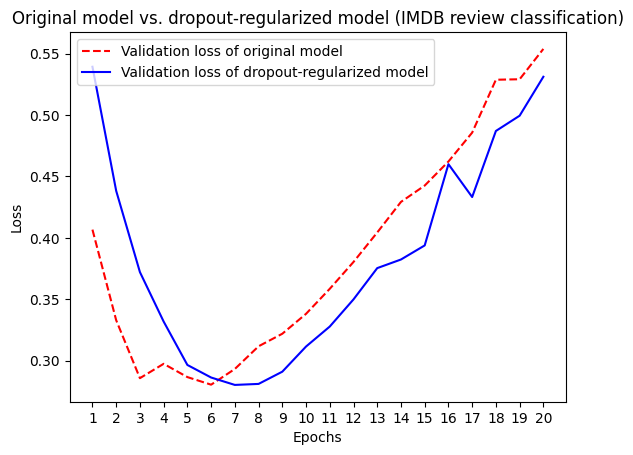

In [30]:
#과대적합 문제해결
#손실정도도 기존 모델과 비슷하다.

original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)
plt.title(
    "Original model vs. dropout-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

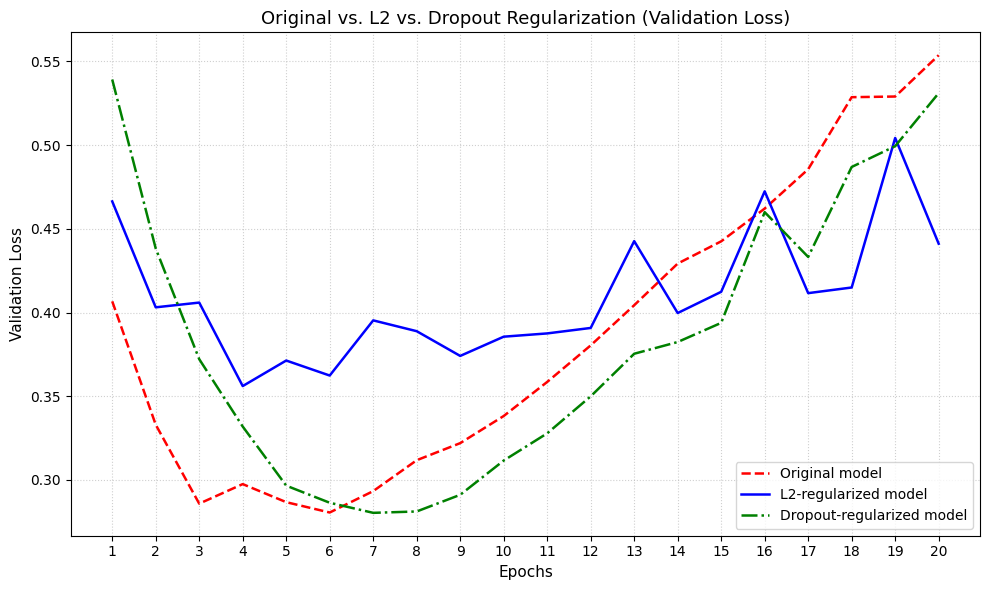

In [31]:
import matplotlib.pyplot as plt

# 1. 각 모델의 검증 손실(val_loss) 추출
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]

# 2. 에포크 범위 설정 (20 에포크 기준)
epochs = range(1, len(original_val_loss) + 1)

# 3. 플롯 크기 및 시각화 구성
plt.figure(figsize=(10, 6))

# (1) Original 모델 (기준선)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    linewidth=1.8,
    label="Original model",
)

# (2) L2 규제 모델
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    linewidth=1.8,
    label="L2-regularized model",
)

# (3) Dropout 규제 모델
plt.plot(
    epochs,
    dropout_val_loss,
    "g-.",
    linewidth=1.8,
    label="Dropout-regularized model",
)

# 4. 차트 라벨, 눈금 및 범례 설정
plt.title(
    "Original vs. L2 vs. Dropout Regularization (Validation Loss)",
    fontsize=13,
)
plt.xlabel("Epochs", fontsize=11)
plt.ylabel("Validation Loss", fontsize=11)
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)

# 5. 출력
plt.tight_layout()
plt.show()

In [32]:
# Without hidden Dense layers it is exactly a (multi-class) logistic regression, try this, study logistic regression on mnist data
# Try with one-hot encoded labels


import keras
from keras import layers
from keras.datasets import mnist
from keras.utils import to_categorical

#원핫인코딩을 통한 데이터 벡터화
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
train_data = train_images.reshape((60000, 28 * 28)).astype("float32") / 255
test_data = test_images.reshape((10000, 28 * 28)).astype("float32") / 255
train_labels_one_hot = to_categorical(train_labels)
test_labels_one_hot = to_categorical(test_labels)


model = keras.Sequential([
    # layers.Dense(512, activation="relu"),  # 은닉층 제외
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_logistic = model.fit(
    train_data,
    train_labels_one_hot,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.6392 - loss: 1.4038 - val_accuracy: 0.8215 - val_loss: 0.8520
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8384 - loss: 0.7121 - val_accuracy: 0.8617 - val_loss: 0.5950
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8681 - loss: 0.5471 - val_accuracy: 0.8777 - val_loss: 0.4965
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8820 - loss: 0.4711 - val_accuracy: 0.8873 - val_loss: 0.4441
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8917 - loss: 0.4259 - val_accuracy: 0.8930 - val_loss: 0.4116
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8968 - loss: 0.3958 - val_accuracy: 0.8973 - val_loss: 0.3890
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9019 - loss: 0.3741 - val_accuracy: 0.9004 - val_loss: 0.3729
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9050 - loss: 0.3575 - val_accuracy: 0.9022 - val_loss

#custoem model fit well

In [ ]:
#custom

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_custom = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 52ms/step - accuracy: 0.1140 - loss: -32.5559 - val_accuracy: 0.1095 - val_loss: -53.2747
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1143 - loss: -52.1483 - val_accuracy: 0.1095 - val_loss: -55.0952
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1143 - loss: -54.2644 - val_accuracy: 0.1095 - val_loss: -55.1009
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1143 - loss: -54.6700 - val_accuracy: 0.1095 - val_loss: -55.1009
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1143 - loss: -54.8487 - val_accuracy: 0.1095 - val_loss: -55.1009
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1143 - loss: -54.8952 - val_accuracy: 0.1095 - val_loss: -55.1009
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1143 - loss: -54.9077 - val_accuracy: 0.1095 - val_loss: -55.1009
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1143 - loss: -54.9337 - v

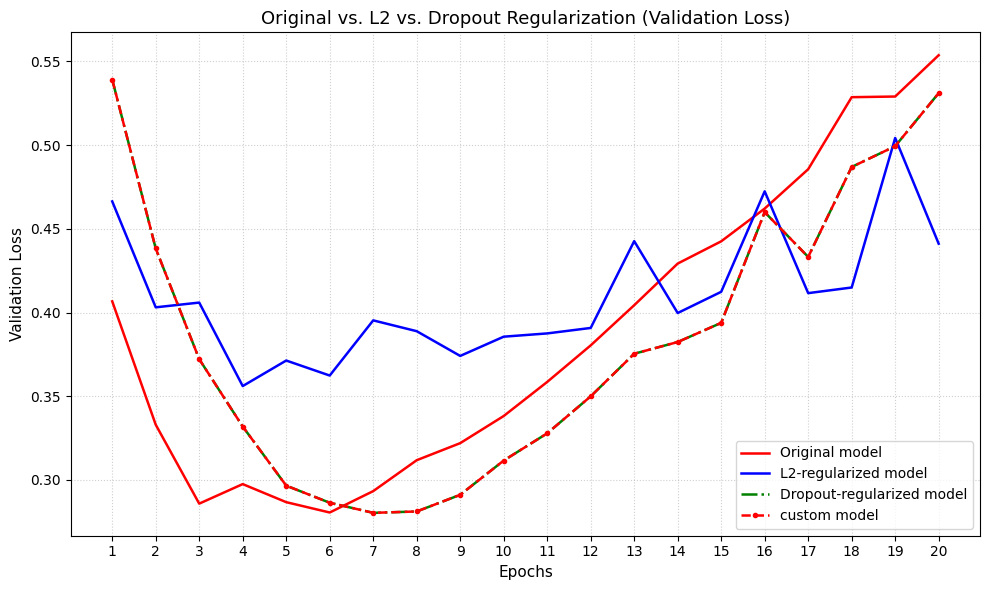

In [34]:
import matplotlib.pyplot as plt

# 1. 각 모델의 검증 손실(val_loss) 추출
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]


# 2. 에포크 범위 설정 (20 에포크 기준)
epochs = range(1, len(original_val_loss) + 1)

# 3. 플롯 크기 및 시각화 구성
plt.figure(figsize=(10, 6))

# (1) Original 모델 (기준선)
plt.plot(
    epochs,
    original_val_loss,
    "r-",
    linewidth=1.8,
    label="Original model",
)

# (2) L2 규제 모델
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    linewidth=1.8,
    label="L2-regularized model",
)

# (3) Dropout 규제 모델
plt.plot(
    epochs,
    dropout_val_loss,
    "g-.",
    linewidth=1.8,
    label="Dropout-regularized model",
)

# (4) custom 모델
plt.plot(
    epochs,
    dropout_val_loss,
    "r--.",
    linewidth=1.8,
    label="custom model",
)


# 4. 차트 라벨, 눈금 및 범례 설정
plt.title(
    "Original vs. L2 vs. Dropout Regularization (Validation Loss)",
    fontsize=13,
)
plt.xlabel("Epochs", fontsize=11)
plt.ylabel("Validation Loss", fontsize=11)
plt.xticks(epochs)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(fontsize=10)

# 5. 출력
plt.tight_layout()
plt.show()